<!-- config-banner -->
# DINO 1° forward — 200-year spin-up (crashed)

**`viscD2x_Zref`** — 200 yr from rest; `viscAhDfile` = `dino_viscAhD_2p00.bin` (2× reference) but `viscAhZfile` = `dino_viscAhD.bin` (reference), through `PARM05`. Run 19369, **crashed at 126.3 yr**. Raising `viscAhZ` to 2× as well is what became `visc2x` (run 28463).


In [1]:
%load_ext autoreload
%autoreload 2

%load_ext autoreload loads the Jupyter autoreload extension, and %autoreload 2 automatically reloads all imported Python modules before each cell runs so changes in .py files take effect without restarting the kernel.

In [2]:
from dinocean.neverworld2.loader import *
from dinocean.neverworld2.plotter import *
import numpy as np
import xarray as xr
from pathlib import Path
import glob
import xmitgcm

import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings("ignore")

In [3]:
## Use the following commands to know where the package dinoocean is installed

# import dinocean
# dinocean.__path__

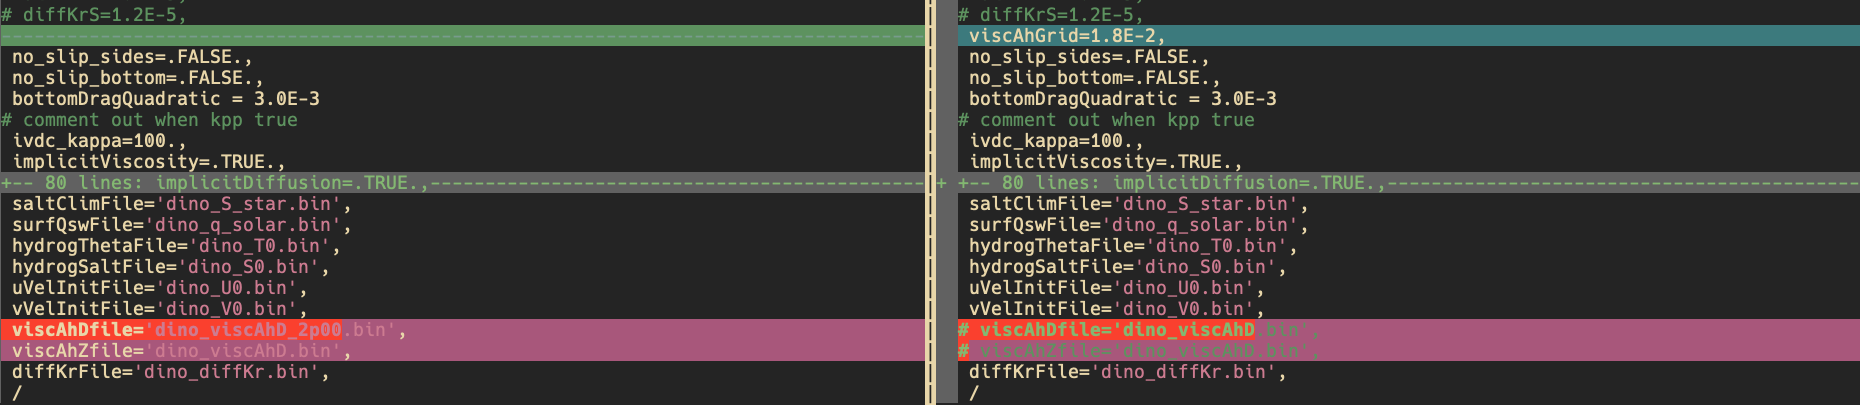

left one I am using

In [4]:
# -------------------------------
# User inputs
# -------------------------------
run_dir = Path("/scratch2/tshahriar/DINO_1deg_frd_runs/runs_prod/crashed_runs/DINO_1deg_frd_200yr_from_rest_viscD2x_Zref_crashed_126p3y_run19369/")
grid_dir = run_dir  # change if your grid files live elsewhere

prefix = ["dynDiag", "surfDiag", "atmDiag", "viscDiag"]
ref = np.datetime64("2000-01-01T00:00:00")
delta_t = 1800.0

In [5]:
d_entire = DINOLoader(
    run_dir=str(run_dir),          # Experiment output directory
    ref_date=ref,
    prefix=prefix,    
    niters=None,                # Number of diagnostic timesteps to load
    iters_type='last',        
    delta_t=delta_t            # Model timestep in seconds (must match MITgcm deltaT)
)

In [6]:
# DINOPlotter(d_entire).plot_psi()

In [7]:
d_last10y = DINOLoader(
    run_dir=str(run_dir),          # Experiment output directory
    ref_date=ref,
    prefix=prefix,    # Which MITgcm diagnostics to load
    niters=120,                # Number of diagnostic timesteps to load
    iters_type='last',    # Evenly sample timesteps across entire run
    delta_t=delta_t            # Model timestep in seconds (must match MITgcm deltaT)
)

d_last10y

In [8]:
d_last10y.ds

<xarray.Dataset>
Dimensions:   (i: 51, i_g: 51, j: 198, j_g: 198, k: 36, k_u: 36, k_l: 36,
               k_p1: 37, time: 120)
Coordinates: (12/44)
  * i         (i) int64 0 1 2 3 4 5 6 7 8 9 10 ... 41 42 43 44 45 46 47 48 49 50
  * i_g       (i_g) int64 0 1 2 3 4 5 6 7 8 9 ... 41 42 43 44 45 46 47 48 49 50
  * j         (j) int64 0 1 2 3 4 5 6 7 8 ... 190 191 192 193 194 195 196 197
  * j_g       (j_g) int64 0 1 2 3 4 5 6 7 8 ... 190 191 192 193 194 195 196 197
  * k         (k) int64 0 1 2 3 4 5 6 7 8 9 10 ... 26 27 28 29 30 31 32 33 34 35
  * k_u       (k_u) int64 0 1 2 3 4 5 6 7 8 9 ... 26 27 28 29 30 31 32 33 34 35
    ...        ...
    dxF       (j, i) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyF       (j, i) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dxV       (j_g, i_g) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    dyU       (j_g, i_g) >f4 dask.array<chunksize=(198, 51), meta=np.ndarray>
    iter      (time) int64 dask.array<chunksize=(1,), meta=np.ndarray>
  * time      (time) datetime64[ns] 2116-07-29 ... 2126-07-06T12:00:00
Data variables: (12/19)
    VISCAHZ   (time, k, j_g, i_g) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    VISCAHD   (time, k, j, i) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    oceTAUX   (time, j, i_g) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    oceTAUY   (time, j_g, i) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    oceQnet   (time, j, i) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    THETA     (time, k, j, i) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    ...        ...
    TRELAX    (time, j, i) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    SRELAX    (time, j, i) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    MXLDEPTH  (time, j, i) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    PHIBOT    (time, j, i) float32 dask.array<chunksize=(1, 198, 51), meta=np.ndarray>
    sigma2    (time, k, j, i) float32 dask.array<chunksize=(1, 36, 198, 51), meta=np.ndarray>
    psi_c     (time, j, i) float32 dask.array<chunksize=(1, 198, 50), meta=np.ndarray>
Attributes:
    Conventions:  CF-1.6
    title:        netCDF wrapper of MITgcm MDS binary data
    source:       MITgcm
    history:      Created by calling `open_mdsdataset(grid_dir='/scratch2/tsh...

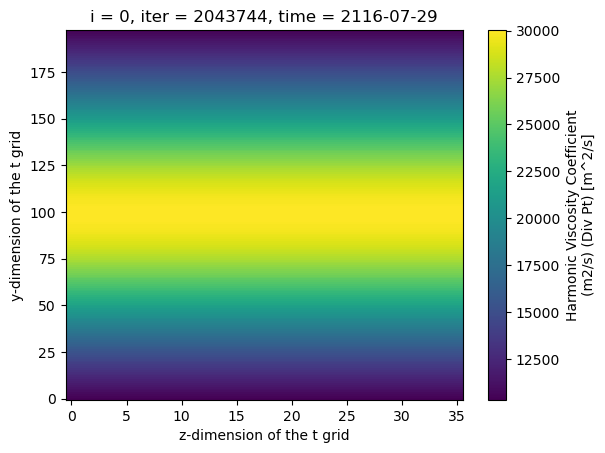

In [9]:
d_last10y.ds.VISCAHD[0][:,:,0].T.plot()

In [10]:
jmid = d_last10y.ds.VISCAHD[0][:,:,0].T.sizes['j'] // 2 #=98

m1_mid = d_last10y.ds.VISCAHD[0][:,:,0].T.isel(j=jmid).mean().compute().item()

print(f"Middle-Y mean VISCAHD : {m1_mid}")

Middle-Y mean VISCAHD : 30023.7109375


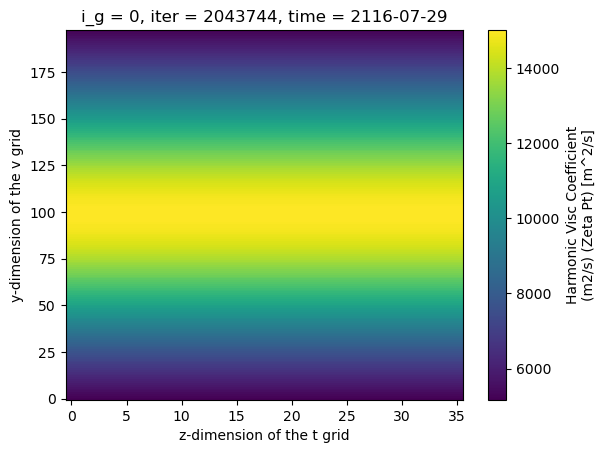

In [11]:
d_last10y.ds.VISCAHZ[0][:,:,0].T.plot()

In [12]:
jmid = d_last10y.ds.VISCAHZ[0][:,:,0].T.sizes['j_g'] // 2 #=98

m1_mid = d_last10y.ds.VISCAHZ[0][:,:,0].T.isel(j_g=jmid).mean().compute().item()

print(f"Middle-Y mean VISCAHZ : {m1_mid}")

Middle-Y mean VISCAHZ : 15011.85546875


In [13]:
# ds = xmitgcm.open_mdsdataset(run_from_pickup, prefix=['surfDiag', 'dynDiag'], geometry='curvilinear', delta_t=1800)
# ds

In [14]:
# ds.THETA.max(ds.hFacC.dims).plot()

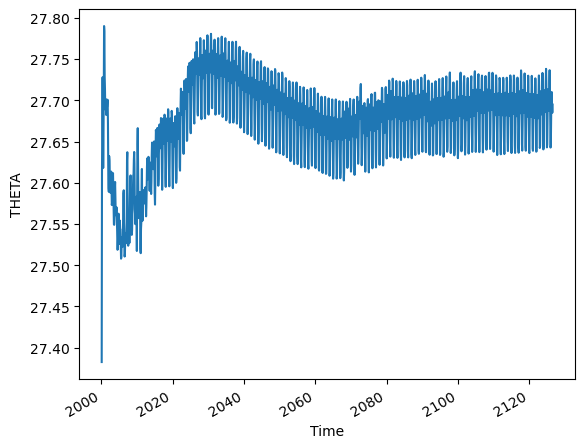

In [15]:
d_entire.ds.THETA.max(d_entire.ds.hFacC.dims).plot()

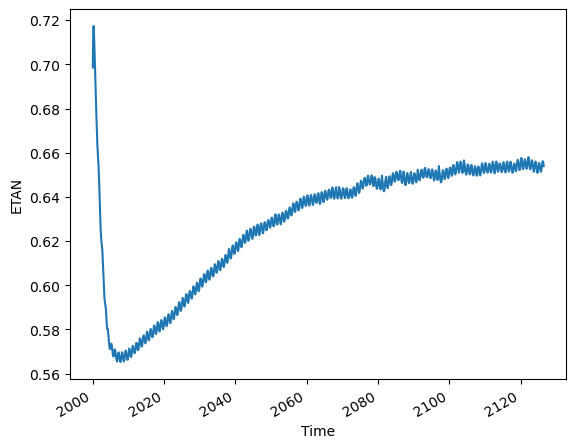

In [16]:
d_entire.ds.ETAN.max(d_entire.ds.hFacC[0].dims).plot()

In [17]:
# d_last10y.ds.ETAN.plot(col='time')

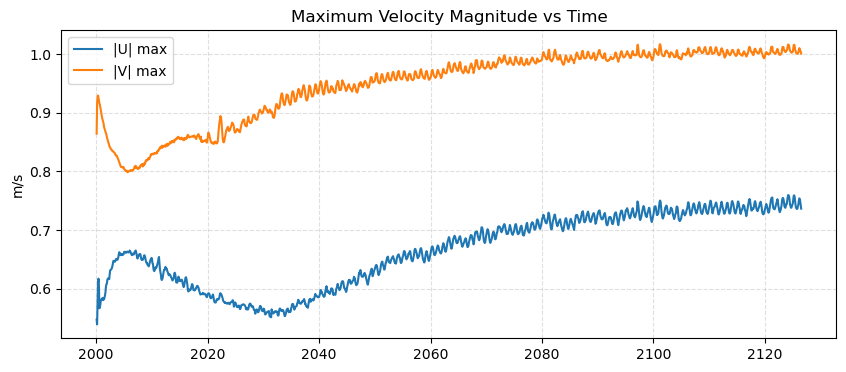

In [18]:
# --- Absolute velocities ---
u_abs = np.abs(d_entire.ds.UVEL)
v_abs = np.abs(d_entire.ds.VVEL)

# --- Spatial dimensions (exclude time) ---
u_dims = [dim for dim in u_abs.dims if dim != "time"]
v_dims = [dim for dim in v_abs.dims if dim != "time"]

# --- Maximum over space ---
u_max = u_abs.max(dim=u_dims)
v_max = v_abs.max(dim=v_dims)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(d_entire.ds.time, u_max, label="|U| max")
ax.plot(d_entire.ds.time, v_max, label="|V| max")

ax.set_ylabel("m/s")
ax.set_title("Maximum Velocity Magnitude vs Time")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()

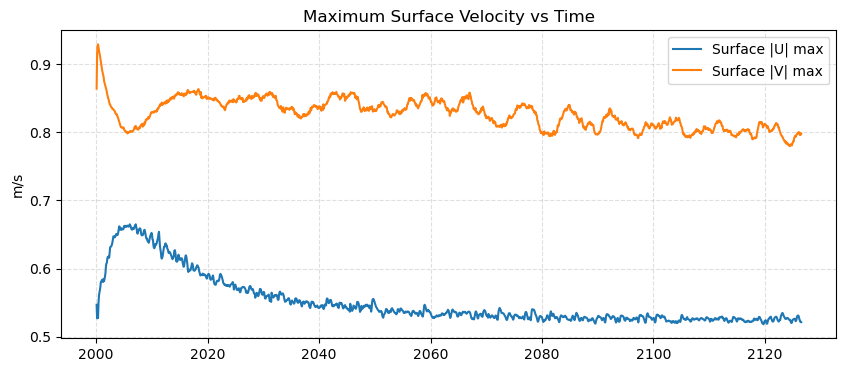

In [19]:
# --- Surface velocities ---
u_surf = d_entire.ds.UVEL.isel(k=0)
v_surf = d_entire.ds.VVEL.isel(k=0)

# --- Absolute value ---
u_abs = np.abs(u_surf)
v_abs = np.abs(v_surf)

# --- Horizontal dimensions ---
u_dims = [dim for dim in u_abs.dims if dim != "time"]
v_dims = [dim for dim in v_abs.dims if dim != "time"]

# --- Max over space ---
u_surf_max = u_abs.max(dim=u_dims)
v_surf_max = v_abs.max(dim=v_dims)

# --- Plot ---
fig, ax = plt.subplots(figsize=(10,4))

ax.plot(d_entire.ds.time, u_surf_max, label="Surface |U| max")
ax.plot(d_entire.ds.time, v_surf_max, label="Surface |V| max")

ax.set_ylabel("m/s")
ax.set_title("Maximum Surface Velocity vs Time")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.4)

plt.show()

In [20]:
# # --- Compute surface speed ---
# speed_surf = np.sqrt(
#     d_entire.ds.UVEL.isel(k=0)**2 +
#     d_entire.ds.VVEL.isel(k=0)**2
# )

# # --- Horizontal dimensions ---
# speed_surf_dims = [dim for dim in speed_surf.dims if dim != "time"]

# # --- Maximum over space ---
# speed_surf_max = speed_surf.max(dim=speed_surf_dims)

# # --- Plot ---
# fig, ax = plt.subplots(figsize=(10,4))

# ax.plot(d_entire.ds.time, speed_surf_max, linewidth=2)

# ax.set_ylabel("Speed [m s$^{-1}$]")
# ax.set_xlabel("Time")
# ax.set_title("Maximum Surface Speed vs Time")
# ax.grid(True, linestyle="--", alpha=0.4)

# plt.show()

(<Figure size 1000x600 with 2 Axes>,
 <Axes: title={'center': 'MOC Depth Space (Time-Averaged)'}, xlabel='Latitude [$^\\circ$N]', ylabel='Depth [m]'>)

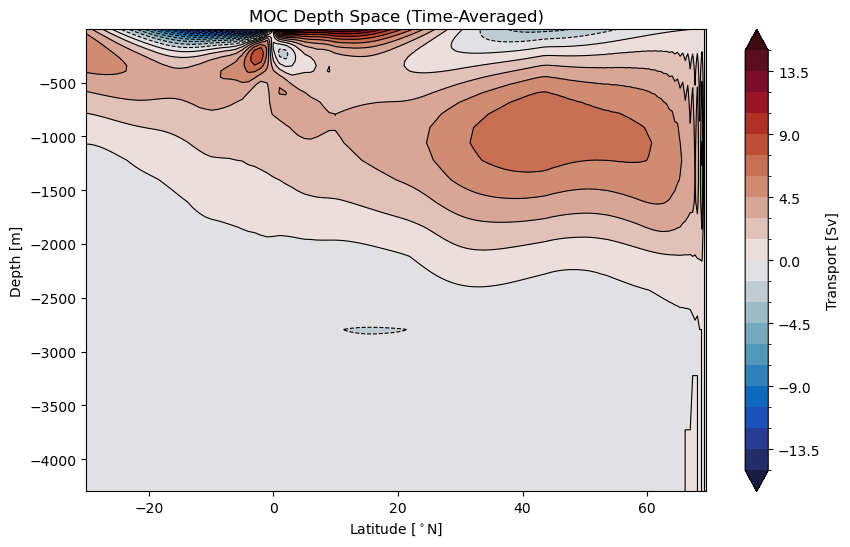

In [21]:
# d_last10y.plot_moc_depth_space(timemean=True)
DINOPlotter(d_last10y).plot_moc_depth_space(timemean=True)

(<Figure size 1000x600 with 2 Axes>,
 <Axes: title={'center': 'MOC Density Space (Time-Averaged)'}>)

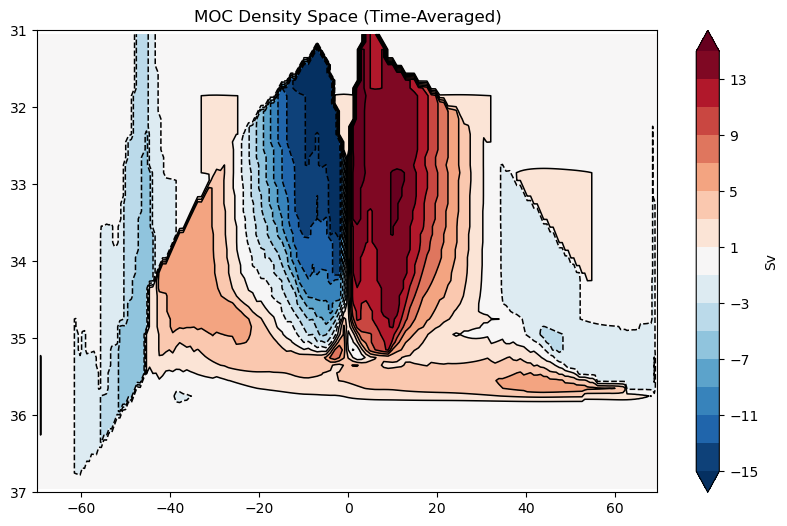

In [22]:
# d_last10y.plot_moc_density_space(timemean=True)
DINOPlotter(d_last10y).plot_moc_density_space(timemean=True)

In [23]:
# from dinocean.neverworld2.gif import *
# import os

# # Create a subdirectory inside the run directory for figures
# fig_dir = os.path.join(run_dir, "figures_moc_depth")

# gm = GIFmaker(
#     outdir=fig_dir,        # Save frames in run_dir/figures_moc_depth/
#     prefix="moc_depth",    # Frame filename prefix
#     dpi=150                # Figure resolution
# )

# gm.make_frames(
#     nt=d_last10y.nt,                                   # Number of loaded snapshots
#     frame_func=lambda i: d_last10y.plot_moc_depth_space(index_show=i),
#     stride=1,                                 # Plot every snapshot
# )

# gm.show_slider()

# # Optional: create animated GIF
# # gm.to_gif()

(<Figure size 600x1000 with 2 Axes>,
 <Axes: title={'center': 'Barotropic Streamfunction (Time-Averaged)'}, xlabel='x coordinate [m]', ylabel='y coordinate [m]'>)

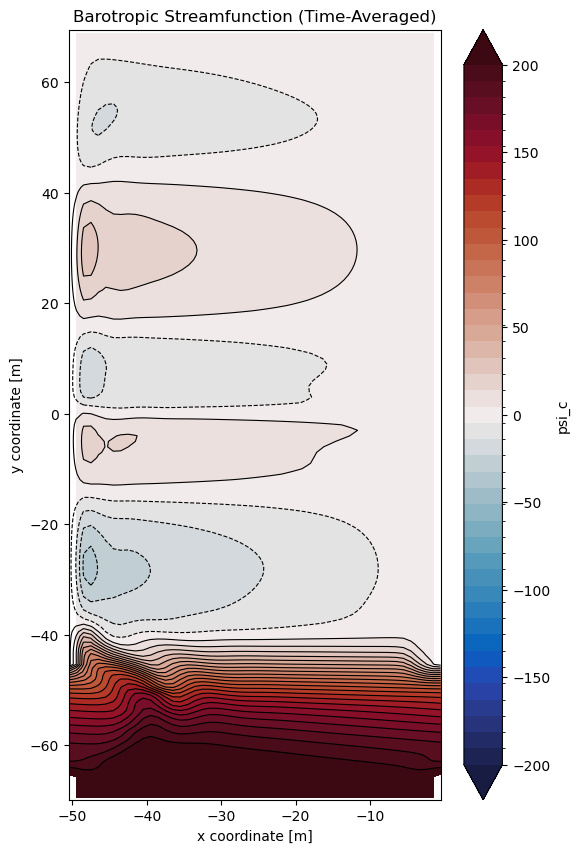

In [24]:
# d_last10y.plot_psi_fancy(timemean=True)

DINOPlotter(d_last10y).plot_psi(timemean=True)

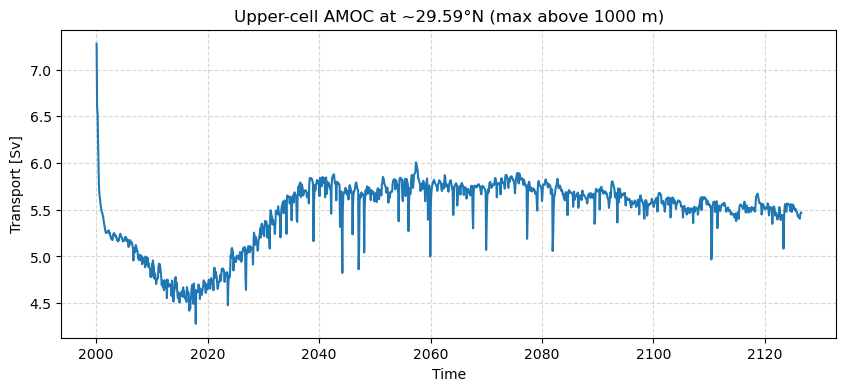

In [25]:
# --- 1) Build MOC (psi_moc) for all loaded times (same math as plot_moc_depth_space) ---
vert_dim = d_entire.vert_dim  # 'k' for curvilinear, else 'Z'

v = d_entire.ds.VVEL  # (time, k, j_g, i)

# Transport in Sv: integrate zonally and over layer thickness + partial cells
transport = (v * d_entire.ds.dxG * d_entire.ds.drF * d_entire.ds.hFacS).sum("i") / 1e6  # (time,k,j_g)

# Streamfunction in depth-space: cumulative sum from surface downward (same as package)
psi_moc = transport.sortby(vert_dim, ascending=True).cumsum(vert_dim)  # (time,k,j_g)

# Attach latitude coordinate to j_g (V-grid latitude)
lat = d_entire.ds.YC.isel(i=0).rename({"j": "j_g"})
psi_moc = psi_moc.assign_coords(YC=lat)

# --- 2) Select latitude closest to 30N ---
target_lat = 30.0
j_sel = int(np.abs(psi_moc.YC - target_lat).argmin("j_g").values)
lat_sel = float(psi_moc.YC.isel(j_g=j_sel).values)

# --- 3) Restrict to upper 1000 m and take the max over depth ---
# In MITgcm, Z is typically 0 at surface and NEGATIVE downward (meters)
z = d_entire.ds.Z if "Z" in d_entire.ds else d_entire.ds[vert_dim]
upper_mask = (z >= -1000)

psi_upper = psi_moc.where(upper_mask, drop=True)              # keep only z >= -1000 m
amoc_upper_30N = psi_upper.isel(j_g=j_sel).max(vert_dim)      # (time,) in Sv

# --- 4) Plot ---
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(d_entire.ds.time.values, amoc_upper_30N.values)
ax.set_title(f"Upper-cell AMOC at ~{lat_sel:.2f}°N (max above 1000 m)")
ax.set_xlabel("Time")
ax.set_ylabel("Transport [Sv]")
ax.grid(True, linestyle="--", alpha=0.5)
plt.show()

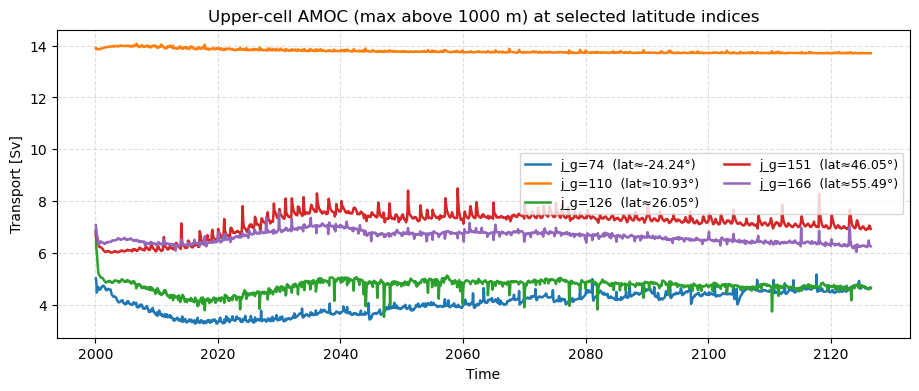

In [26]:
# --- indices you want on the V-grid (j_g) ---
J_list = [74, 110, 126, 151, 166]

vert_dim = d_entire.vert_dim  # 'k' for curvilinear, else 'Z'

# --- build MOC in depth space (same math as plot_moc_depth_space) ---
v = d_entire.ds.VVEL  # (time,k,j_g,i)
transport = (v * d_entire.ds.dxG * d_entire.ds.drF * d_entire.ds.hFacS).sum("i") / 1e6  # Sv
psi_moc = transport.sortby(vert_dim, ascending=True).cumsum(vert_dim)  # Sv

# --- upper 1000 m mask (Z is 0 at surface, negative downward) ---
z = d_entire.ds.Z
psi_upper = psi_moc.where(z >= -1000, drop=True)

# --- get a latitude value for each j_g index (approx: use YC at i=0 and map j -> j_g) ---
# If j_g and j have same length, this works directly; otherwise we fall back to indexing safely.
yc_1d = d_entire.ds.YC.isel(i=0)
def lat_at_jg(jg):
    if "j_g" in yc_1d.dims:
        return float(yc_1d.isel(j_g=jg).values)
    elif "j" in yc_1d.dims and (jg < yc_1d.sizes["j"]):
        return float(yc_1d.isel(j=jg).values)
    else:
        return float("nan")

lat_list = [lat_at_jg(jg) for jg in J_list]

# --- compute upper-cell AMOC time series for each section (max above 1000 m) ---
amoc_ts_list = []
for jg in J_list:
    amoc_ts = psi_upper.isel(j_g=jg).max(vert_dim)  # (time,)
    amoc_ts_list.append(amoc_ts)

# --- plot ---
fig, ax = plt.subplots(figsize=(11, 4))

for jg, latv, amoc_ts in zip(J_list, lat_list, amoc_ts_list):
    lab = f"j_g={jg}  (lat≈{latv:.2f}°)"
    ax.plot(d_entire.ds.time.values, amoc_ts.values, label=lab, lw=1.8)

ax.set_title("Upper-cell AMOC (max above 1000 m) at selected latitude indices")
ax.set_xlabel("Time")
ax.set_ylabel("Transport [Sv]")
ax.grid(True, linestyle="--", alpha=0.4)
ax.legend(ncol=2, fontsize=9)

plt.show()

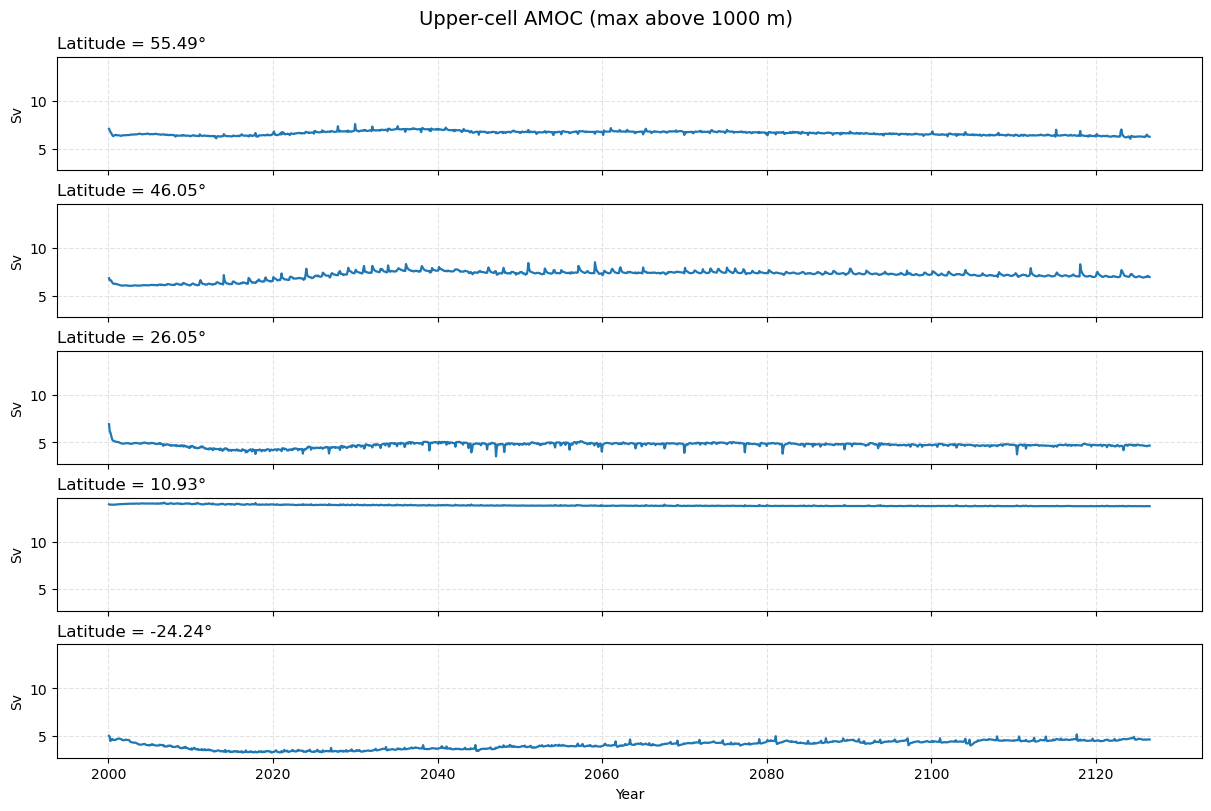

In [27]:
# --- your V-grid indices ---
J_list = [74, 110, 126, 151, 166]

vert_dim = d_entire.vert_dim

# --- Build MOC ---
v = d_entire.ds.VVEL
transport = (v * d_entire.ds.dxG * d_entire.ds.drF * d_entire.ds.hFacS).sum("i") / 1e6
psi_moc = transport.sortby(vert_dim, ascending=True).cumsum(vert_dim)

# --- Upper 1000 m ---
psi_upper = psi_moc.where(d_entire.ds.Z >= -1000, drop=True)

# --- Get latitudes (from YC at i=0) ---
yc_1d = d_entire.ds.YC.isel(i=0)
lat_list = [round(float(yc_1d.isel(j=jg).values), 2) for jg in J_list]

# --- Compute AMOC time series ---
amoc_list = [psi_upper.isel(j_g=jg).max(vert_dim) for jg in J_list]

# --- Sort so smallest latitude is at bottom ---
combined = sorted(zip(lat_list, amoc_list), key=lambda x: x[0])
lat_sorted, amoc_sorted = zip(*combined)

# --- Plot ---
n = len(lat_sorted)
fig, axes = plt.subplots(n, 1, figsize=(12, 8), sharex=True, constrained_layout=True)

# Optional common y-limits
ymin = min(float(ts.min()) for ts in amoc_sorted)
ymax = max(float(ts.max()) for ts in amoc_sorted)
pad = 0.05 * (ymax - ymin)
ylims = (ymin - pad, ymax + pad)

for ax, latv, ts in zip(axes[::-1], lat_sorted, amoc_sorted):
    ax.plot(d_entire.ds.time.values, ts.values, linewidth=1.6)
    ax.set_ylabel("Sv")
    ax.set_ylim(*ylims)
    ax.set_title(f"Latitude = {latv}°", loc="left")
    ax.grid(True, linestyle="--", alpha=0.35)

axes[-1].set_xlabel("Year")

fig.suptitle("Upper-cell AMOC (max above 1000 m)", fontsize=14)
plt.show()

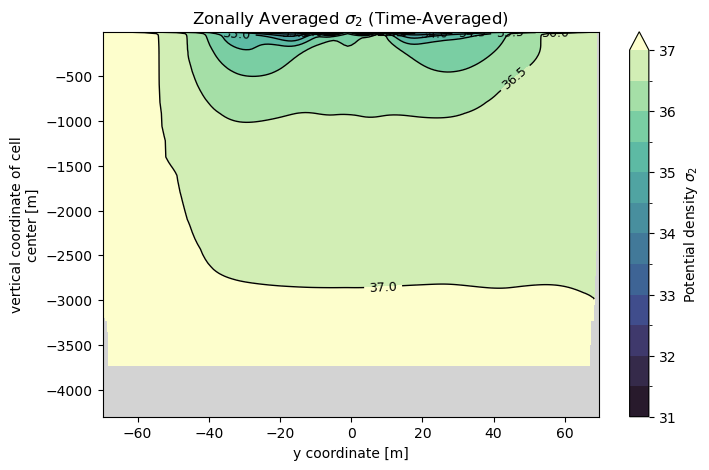

In [28]:
# Time-mean meridional section of sigma2 (zonally averaged)
fig, ax = DINOPlotter(d_last10y).plot_sigma2_sections(timemean=True)
plt.show()

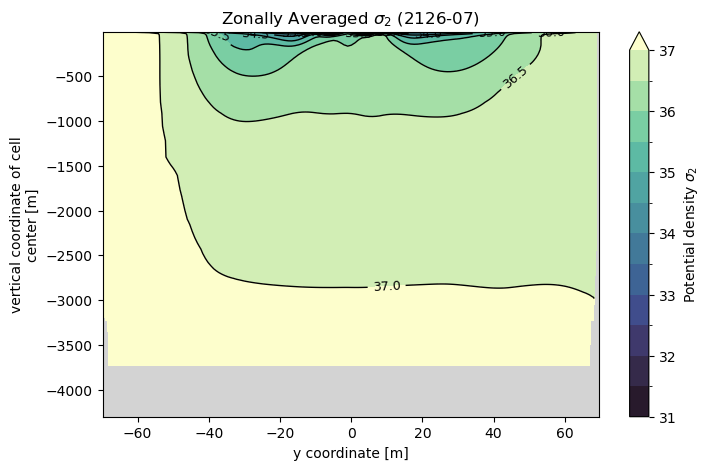

In [29]:
fig, ax = DINOPlotter(d_last10y).plot_sigma2_sections(index_show=-1, timemean=False)
plt.show()